# TP1 :  Analisis de redes de transporte (Airport)

In [ ]:
# @title Cargar Bibliotecas
import matplotlib.pyplot as plt
import os

# Números y Datos
import numpy as np
import networkx as nx
from networkx.algorithms.approximation import average_clustering
import community.community_louvain as cl

import pandas as pd
import pickle


from dotenv import load_dotenv, find_dotenv
load_dotenv(find_dotenv())
import time

### Cargar datos

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
path="/content/drive/MyDrive/Maestria/Materias/DataMiningCienciaTecnologia/TP1/datasets/"
#path= os.getenv("DATA_PATH") + "/TP1/datasets/"

In [ ]:
df = pd.read_csv(path + 'airport_graph.csv')

# Agregar pasajeros para cada par origen-destino
df_agg = (
    df.groupby(
        ['ORIGIN_AIRPORT_ID', 'DEST_AIRPORT_ID'],
        as_index=False
    )['PASSENGERS']
    .sum()
)

# Renombrar PASSENGERS -> weight
df_agg.rename(columns={'PASSENGERS': 'weight'}, inplace=True)

# Crear grafo dirigido
air = nx.from_pandas_edgelist(
    df_agg,
    source='ORIGIN_AIRPORT_ID',
    target='DEST_AIRPORT_ID',
    edge_attr=['weight'],
    create_using=nx.DiGraph()
)

In [ ]:
# fomato graphml
filename =path + 'bariloche_calles.graphml'
G = nx.read_graphml(filename)

## Datos Airport

## Descripcion

In [ ]:
print('Airport')
print(air)
print('Es dirigido?:',nx.is_directed(air))
print('Es pesado?:',nx.is_weighted(air))
print('Es fuertemente conexo?:',nx.is_strongly_connected(air))
print('Es debilmente conexo?:',nx.is_weakly_connected(air))

Airport
DiGraph with 1252 nodes and 23092 edges
Es dirigido?: True
Es pesado?: True
Es fuertemente conexo?: False
Es debilmente conexo?: False


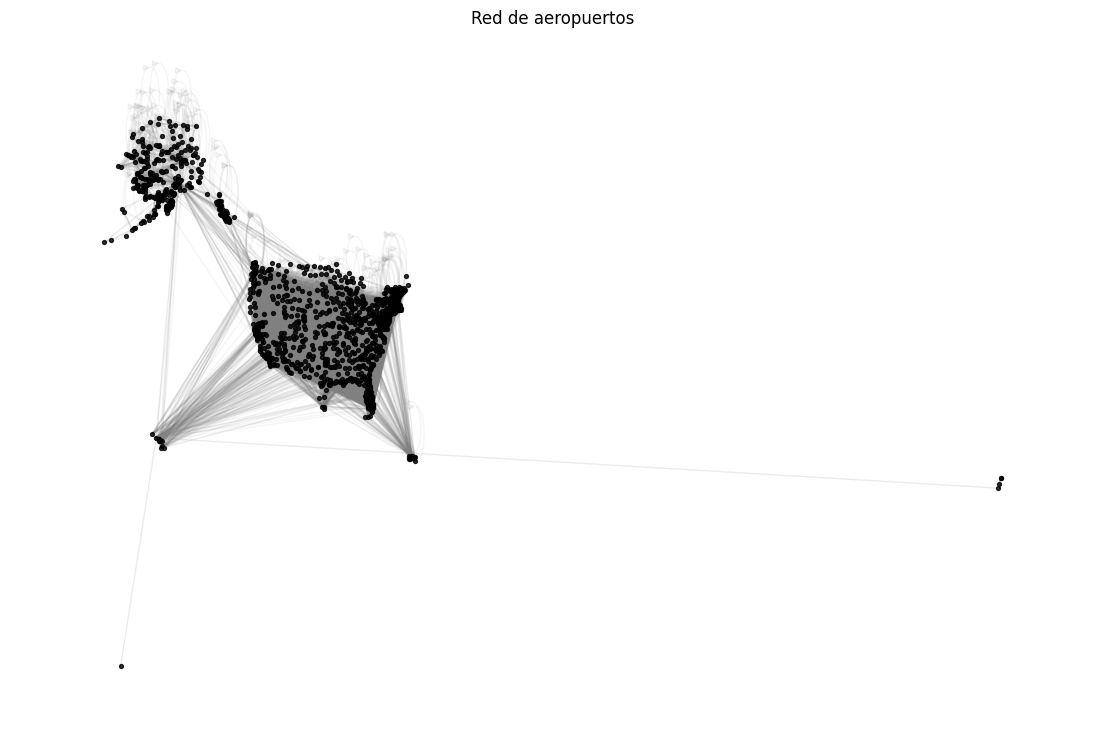

In [ ]:
# @title Grafico red aeropuerto
# Coordenadas
coords = pd.read_csv(path + 'airport_coords.csv')
pos = {
    row['AIRPORT_ID']: (row['LONGITUDE'], row['LATITUDE'])
    for _, row in coords.iterrows()
}

# Me quedo solo con nodos que tengan coordenadas
air_plot = air.subgraph([n for n in air.nodes() if n in pos]).copy()

plt.figure(figsize=(14, 9))

nx.draw_networkx_edges(
    air_plot,
    pos,
    edge_color='gray',
    alpha=0.08,
    arrows=False
)

nx.draw_networkx_nodes(
    air_plot,
    pos,
    node_size=8,
    node_color='black',
    alpha=0.8
)

plt.title('Red de aeropuertos')
plt.axis('off')
plt.show()

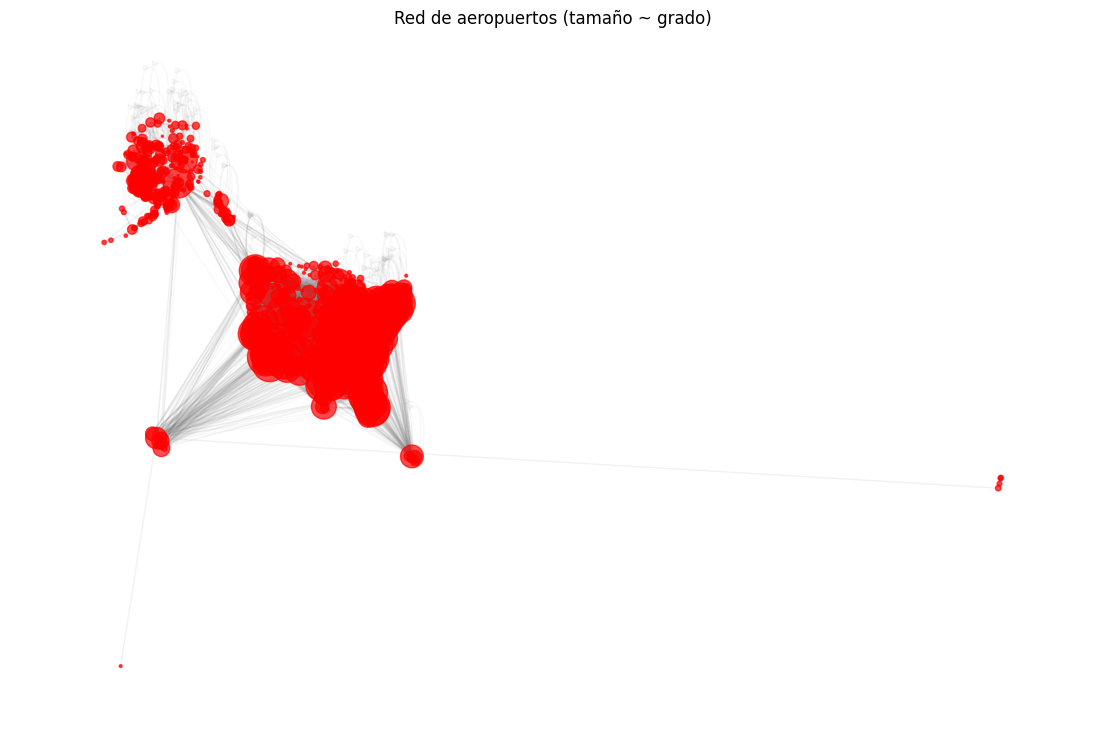

In [ ]:
# @title Grafico red aeropuerto nodo pesado por grado
degree = dict(air_plot.degree())

node_sizes = [degree[n]*2 for n in air_plot.nodes()]
plt.figure(figsize=(14,9))

nx.draw_networkx_edges(
    air_plot, pos,
    edge_color='gray',
    alpha=0.05,
    arrows=False
)

nx.draw_networkx_nodes(
    air_plot, pos,
    node_size=node_sizes,
    node_color='red',
    alpha=0.7
)

plt.title("Red de aeropuertos (tamaño ~ grado)")
plt.axis('off')
plt.show()


In [ ]:
# @title Direccionalidad: reciprocidad
nx.reciprocity(air)



0.8128356140654772

In [ ]:
# @title Componentes fuertemente conexas
scc = list(nx.strongly_connected_components(air))
sizes = [len(c) for c in scc]

print(sorted(sizes, reverse=True)[:10])


[1130, 2, 2, 2, 2, 1, 1, 1, 1, 1]


In [ ]:
# @title Componentes debilmente conexas
wcc = list(nx.weakly_connected_components(air))
sizes_wcc = [len(c) for c in wcc]

print(sorted(sizes_wcc, reverse=True)[:10])

[1239, 3, 2, 2, 2, 2, 2]


In [ ]:
# @title Proporcion de nodos en la componete
giant_size = max(sizes)
total_nodes = air.number_of_nodes()

print(giant_size / total_nodes)

0.902555910543131


In [ ]:
# @title Componente gigante fuertemente conexa
airStronglyCC = sorted(nx.strongly_connected_components(air), key=len, reverse=True)
airStrongly = air.subgraph(airStronglyCC[0])
print('Airport componente gigante fuertemente conexa')
print(airStrongly)
print('Es dirigido?:',nx.is_directed(airStrongly))
print('Es pesado?:',nx.is_weighted(airStrongly))
print('Es fuertemente conexo?:',nx.is_strongly_connected(airStrongly))
print('Es debilmente conexo?:',nx.is_weakly_connected(airStrongly))

Airport componente gigante fuertemente conexa
DiGraph with 1130 nodes and 22959 edges
Es dirigido?: True
Es pesado?: True
Es fuertemente conexo?: True
Es debilmente conexo?: True


In [ ]:
# @title Caracteristicas generales

print("#Nodos:",air.number_of_nodes())
print("#Enlaces:",air.number_of_edges())
print("Densidad:",nx.density(air))
print("Grado medio",np.mean([d for n,d in air.degree()]))

#Nodos: 1252
#Enlaces: 23092
Densidad: 0.014743476784067953
Grado medio 36.88817891373802


In [ ]:
# @title Caracteristicas generales componente gigante fuertemente conexa
airStronglyCC = sorted(nx.strongly_connected_components(air), key=len, reverse=True)
airStrongly = air.subgraph(airStronglyCC[0])
print("#Nodos:",airStrongly.number_of_nodes())
print("#Enlaces:",airStrongly.number_of_edges())
print("Densidad:",nx.density(airStrongly))
print("Grado medio",np.mean([d for n,d in airStrongly.degree()]))

#Nodos: 1130
#Enlaces: 22959
Densidad: 0.017996190535911647
Grado medio 40.6353982300885


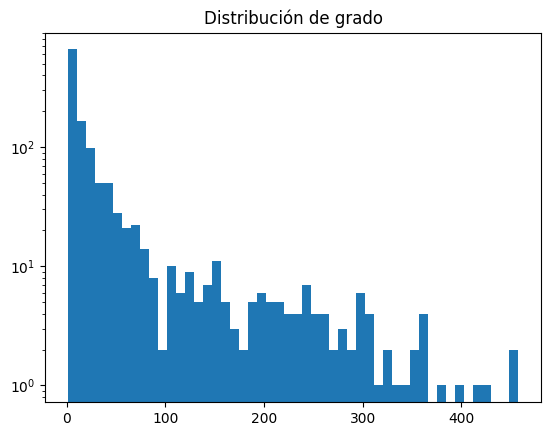

In [ ]:
# @title Distribucion de grado
degrees = [d for n,d in air.degree()]

plt.hist(degrees, bins=50)
plt.yscale('log')
plt.title("Distribución de grado")
plt.show()

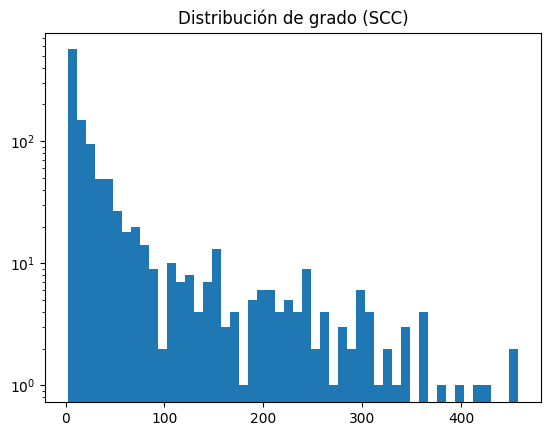

In [ ]:
# @title Distribucion de grado componente fuertemente conexa
degrees_scc = [d for n,d in airStrongly.degree()]

plt.hist(degrees_scc, bins=50)
plt.yscale('log')
plt.title("Distribución de grado (SCC)")
plt.show()

# Centralidad

In [ ]:
# Degree centrality
deg_cent_air = nx.degree_centrality(airStrongly)

# Strength
strength_air = dict(airStrongly.degree(weight="weight"))

# PageRank ponderado por pasajeros
pr_air = nx.pagerank(
    airStrongly,
    weight="weight"
)

# Betweenness SIN peso
bet_air_unw = nx.betweenness_centrality(
    airStrongly,
    normalized=True
)

# Crear peso invertido
for u, v, data in airStrongly.edges(data=True):
    if data["weight"] > 0:
        data["inv_weight"] = 1 / data["weight"]

# Betweenness CON peso
bet_air_w = nx.betweenness_centrality(
    airStrongly,
    weight="inv_weight",
    normalized=True
)

In [ ]:
# @title Funciones
def plotNodeAttribute(G, pos, attribute, exaggeration):
    values = [v for n, v in attribute.items()]

    nsize = np.array(values)
    nsize = exaggeration * (nsize - min(nsize)) / (max(nsize) - min(nsize))

    nx.draw(
        G,
        pos=pos,
        node_size=nsize,
        node_color=values,
        edge_color='gray',
        alpha=0.4
    )


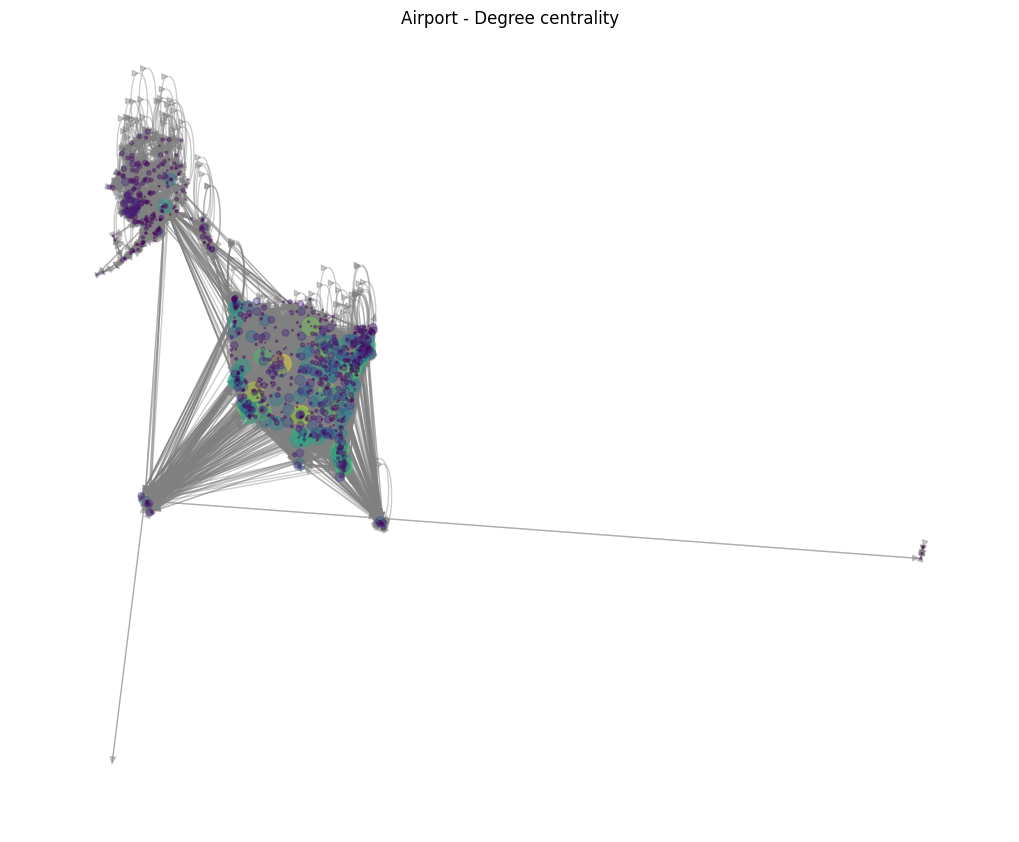

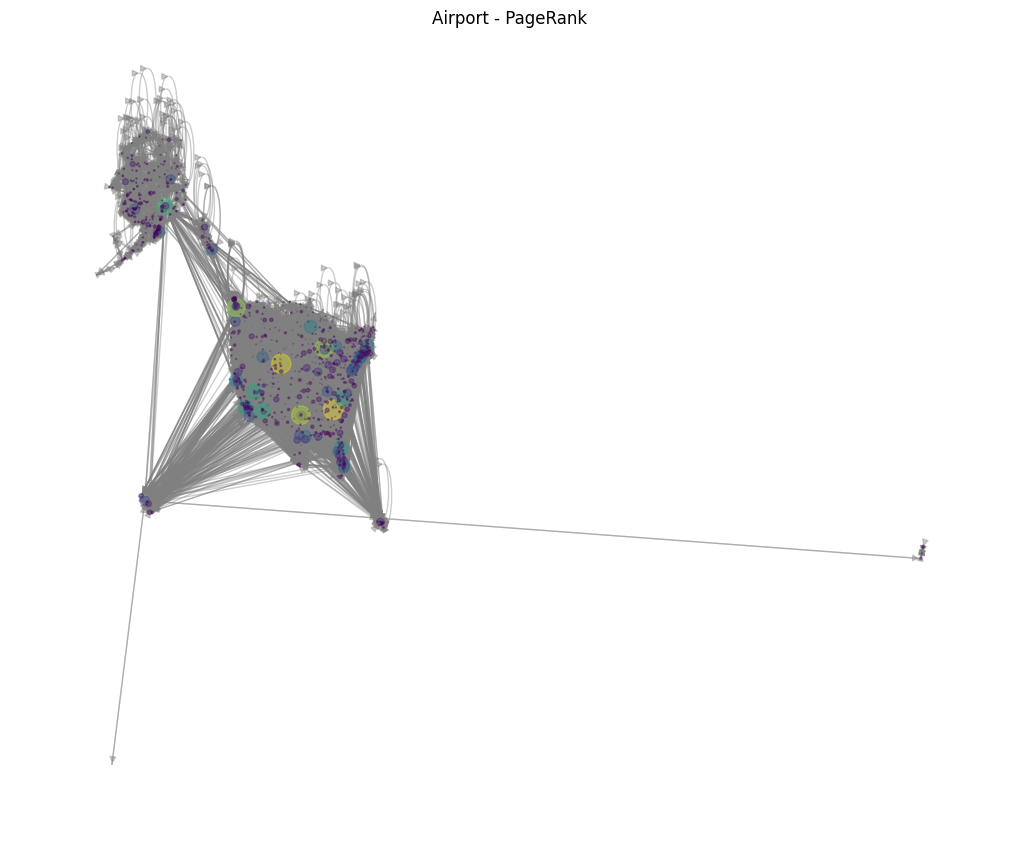

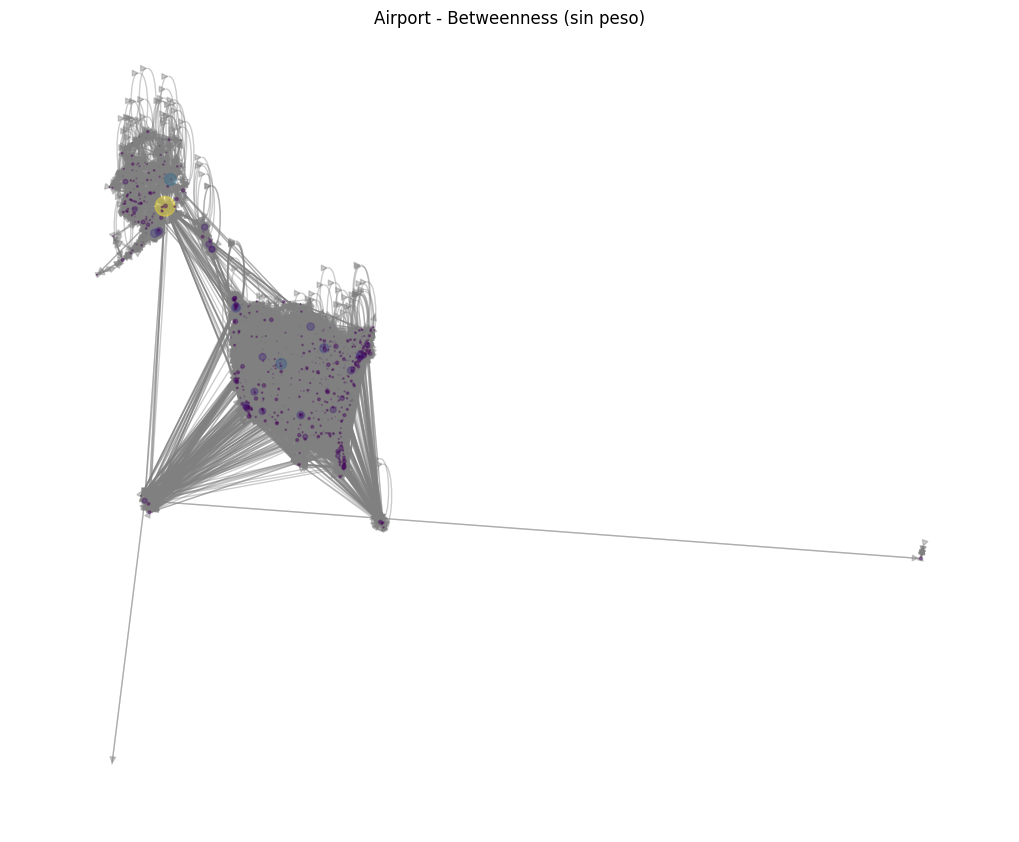

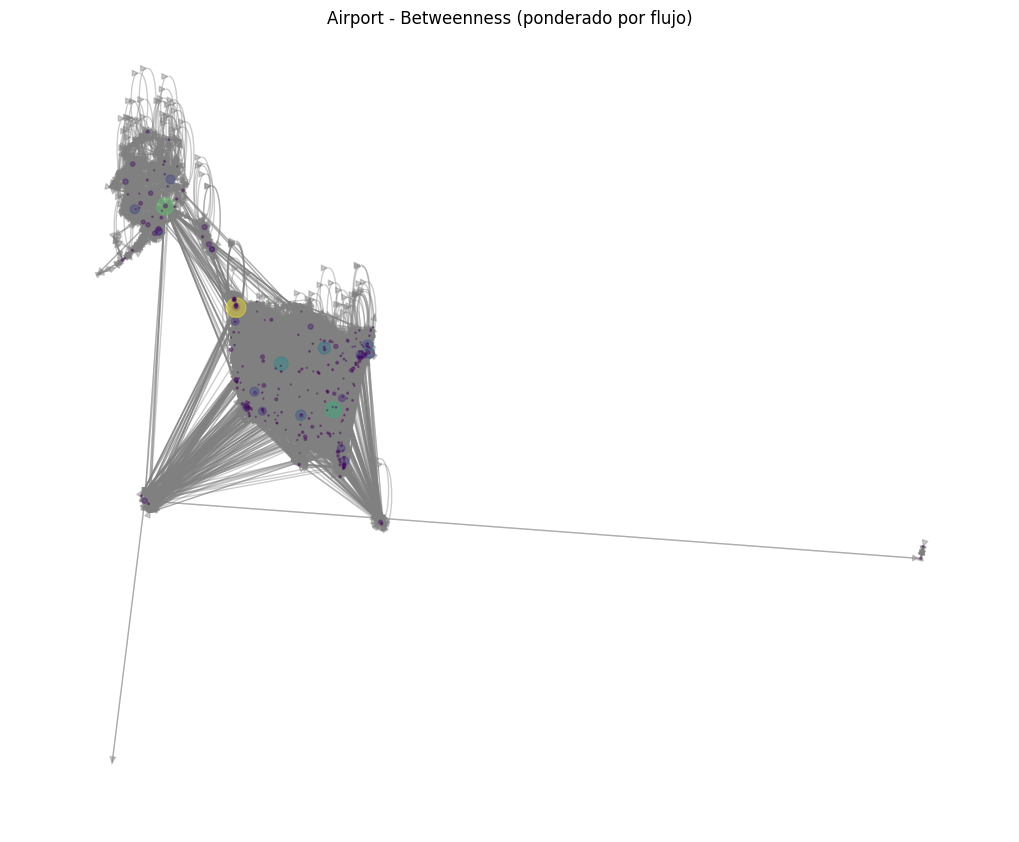

In [ ]:
# @title Graficos

# Degree
plt.figure(figsize=(10,8))
plotNodeAttribute(airStrongly, pos, deg_cent_air, exaggeration=200)
plt.title("Airport - Degree centrality")
plt.show()

# PageRank
plt.figure(figsize=(10,8))
plotNodeAttribute(airStrongly, pos, pr_air, exaggeration=200)
plt.title("Airport - PageRank")
plt.show()

# Betweenness SIN peso
plt.figure(figsize=(10,8))
plotNodeAttribute(airStrongly, pos, bet_air_unw, exaggeration=200)
plt.title("Airport - Betweenness (sin peso)")
plt.show()

# Betweenness CON peso
plt.figure(figsize=(10,8))
plotNodeAttribute(airStrongly, pos, bet_air_w, exaggeration=200)
plt.title("Airport - Betweenness (ponderado por flujo)")
plt.show()

# Robustez

In [ ]:
# @title Funciones
def remove_node_edges(G, node):
    """
    Borra todas las aristas incidentes al nodo, pero NO borra el nodo.
    """
    G.remove_edges_from(list(G.edges(node)))

    if nx.is_directed(G):
        G.remove_edges_from(list(G.in_edges(node)))


def giant_component_fraction(G):
    N = G.number_of_nodes()

    if G.number_of_edges() == 0:
        return 1 / N

    if nx.is_directed(G):
        components = nx.weakly_connected_components(G)
    else:
        components = nx.connected_components(G)

    Ng = len(max(components, key=len))
    return Ng / N


def robustness_analysis(G, node_order, compute_efficiency=False):
    G_temp = G.copy()
    N = G_temp.number_of_nodes()

    fractions_removed = []
    giant_fractions = []
    efficiencies = []

    for i, node in enumerate(node_order):
        remove_node_edges(G_temp, node)

        fractions_removed.append((i + 1) / N)
        giant_fractions.append(giant_component_fraction(G_temp))

        if compute_efficiency:
            efficiencies.append(nx.global_efficiency(G_temp))

    if compute_efficiency:
        return fractions_removed, giant_fractions, efficiencies
    else:
        return fractions_removed, giant_fractions

In [ ]:
G_air = airStrongly.to_undirected().copy()
# Crear peso invertido para usar en betweenness ponderado
for u, v, data in G_air.edges(data=True):
    data["inv_weight"] = 1 / data["weight"]

In [ ]:
# @title Ataque aleatorio
start = time.time()
nodes_air_random = list(G_air.nodes())
np.random.shuffle(nodes_air_random)

x_air_random, Ng_air_random = robustness_analysis(
    G_air,
    nodes_air_random,
    compute_efficiency=False
)

end = time.time()

print(f"Tiempo total: {end - start:.2f} segundos")

Tiempo total: 3.28 segundos


In [ ]:
# @title Ataque dirigido por grado
start = time.time()

degree_air = nx.degree_centrality(G_air)
nodes_air_degree = sorted(degree_air, key=degree_air.get, reverse=True)

x_air_degree, Ng_air_degree = robustness_analysis(
    G_air,
    nodes_air_degree,
    compute_efficiency=False
)

end = time.time()

print(f"Tiempo total: {end - start:.2f} segundos")

Tiempo total: 1.42 segundos


In [ ]:
# @title Ataque dirigido por PageRank
start = time.time()

pagerank_air = nx.pagerank(G_air, weight="weight")  # pasajeros como fuerza del enlace
nodes_air_pr = sorted(pagerank_air, key=pagerank_air.get, reverse=True)

x_air_pr, Ng_air_pr = robustness_analysis(
    G_air,
    nodes_air_pr,
    compute_efficiency=False
)

end = time.time()
print(f"Tiempo total PageRank: {end - start:.2f} segundos")

Tiempo total PageRank: 5.11 segundos


In [ ]:
# @title Ataque dirigido por intermediación SIN peso
start = time.time()

bet_air_unw = nx.betweenness_centrality(
    G_air,
    normalized=True
)

nodes_air_bet_unw = sorted(bet_air_unw, key=bet_air_unw.get, reverse=True)

x_air_bet_unw, Ng_air_bet_unw = robustness_analysis(
    G_air,
    nodes_air_bet_unw,
    compute_efficiency=False
)

end = time.time()
print(f"Tiempo total betweenness sin peso: {end - start:.2f} segundos")

Tiempo total betweenness sin peso: 13.76 segundos


In [ ]:
# @title Ataque dirigido por intermediación ponderada
start = time.time()

bet_air_w = nx.betweenness_centrality(
    G_air,
    weight="inv_weight",
    normalized=True
)

nodes_air_bet_w = sorted(bet_air_w, key=bet_air_w.get, reverse=True)

x_air_bet_w, Ng_air_bet_w = robustness_analysis(
    G_air,
    nodes_air_bet_w,
    compute_efficiency=False
)

end = time.time()
print(f"Tiempo total betweenness ponderado: {end - start:.2f} segundos")

Tiempo total betweenness ponderado: 38.47 segundos


In [ ]:
# @title Ataque dirigido por Strength
start = time.time()

# Strength = suma de pesos incidentes
strength_air = dict(G_air.degree(weight="weight"))

# Ordenar nodos de mayor a menor strength
nodes_air_strength = sorted(
    strength_air,
    key=strength_air.get,
    reverse=True
)

# Robustez
x_air_strength, Ng_air_strength = robustness_analysis(
    G_air,
    nodes_air_strength,
    compute_efficiency=False
)

end = time.time()

print(f"Tiempo total Strength: {end - start:.2f} segundos")

Tiempo total Strength: 1.61 segundos


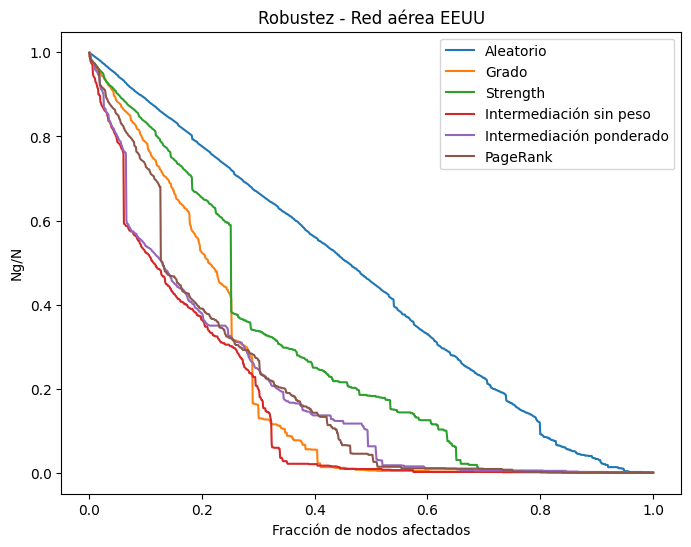

In [ ]:
plt.figure(figsize=(8,6))

plt.plot(x_air_random, Ng_air_random, label="Aleatorio")
plt.plot(x_air_degree, Ng_air_degree, label="Grado")
plt.plot(x_air_strength, Ng_air_strength, label="Strength")
plt.plot(x_air_bet_unw, Ng_air_bet_unw, label="Intermediación sin peso")
plt.plot(x_air_bet_w, Ng_air_bet_w, label="Intermediación ponderado")
plt.plot(x_air_pr, Ng_air_pr, label="PageRank")

plt.xlabel("Fracción de nodos afectados")
plt.ylabel("Ng/N")
plt.title("Robustez - Red aérea EEUU")

plt.legend()

plt.savefig(
    "robustez_airport_con_betweenness.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()